# Análisis y preparación

**Autor:** Andres Felipe Sierra

**Objetivo:** Análisis y preparación de los datos geoespaciales como CHIRPS, SRTM y otros ya sean .tif para su modelamiento de U-Net y Random Forest para determinar las pérdidas. 

**Apreciaciones:** Este script tiene la implementación de CRISP-DM con los respectivos ciclos siendo: Bussiness understanding, Data understanding, Data preparation, Modeling, Evaluation y Deployment. 

### Bussiness understanding

Preparar los datos geoespaciales CRISP-DM(clima) y SRTM(topografícos) para construir un modelo Random Forest para el riesgo agrícola por inundación y deslizamiento, se quiere estimar la exposición, modelar una señal temporal de lluvia que funciones como alerta temprana y realizar triggers parámetricos.

#### Librerias

In [1]:
import pandas as pd
from IPython.display import display
import numpy as ny
import seaborn as sns
from pathlib import Path

import geopandas as gpd
import zipfile

#### Funciones

#### Funciones para obtener las delimitaciones municipales

In [2]:
# Función para extraer los primeros dos dígitos del código municipal y generar una nueva columna de los códigos de los departamentos
def definicion_departamentos_code(dat):
    dat['Depto_Codigo'] = dat['MpCodigo'].str[:2]

    # Observamos cuántos departamentos únicos hay
    print(dat['Depto_Codigo'].unique())
    
    return dat

In [3]:
# Función para obtener los datos .gpkg
def obtener_limites(ruta):
    mun = gpd.read_file(ruta, layer="Limite_Municipal_Poligono")
    mun = definicion_departamentos_code(mun)
    mun = mun[["MpCodigo", "MpNombre", "Depto_Codigo", "geometry"]].to_crs(epsg=4326)
    return mun

In [4]:
# Función para los arreglos básicos
def arreglos_municipios(dat):
    mun = dat[dat.geometry.notna()].copy()
    mun["geometry"] = mun.buffer(0)  # corrige muchas geometrías inválidas
    mun = mun.to_crs(epsg=4326)      # GEE trabaja perfecto en WGS84
    return mun

In [5]:
# Función para renombrar
def renombrar(dat):
    mun = dat.rename(columns={
        "MpCodigo": "MPCOD",
        "MpNombre": "MPNOM",
        "Depto_Codigo": "DEPCOD"
    })
    mun["MPCOD"] = mun["MPCOD"].astype(str)
    return mun

In [6]:
# Función para exportar Shapefile
def Exportar_shapefile(dat):
    out_dir = Path("gee_upload_igac_mun")
    out_dir.mkdir(exist_ok=True)

    shp_path = out_dir / "igac_mun.shp"
    dat.to_file(shp_path, driver="ESRI Shapefile", encoding="UTF-8")

    zip_path = out_dir / "igac_mun.zip"
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
        for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg"]:
            f = shp_path.with_suffix(ext)
            if f.exists():
                z.write(f, arcname=f.name)

    print("Listo para subir a GEE:", zip_path.resolve())

#### Funciones generales

In [7]:
# Función para cargar documentos .csv
def carga_csv(nam,tipo):
    lo = pd.read_csv(nam, dtype={tipo: "string"}, encoding="utf-8")
    return lo

In [8]:
# Función para cargar datos chirps
def carga_chirps_csv(dat,tipo):
    chirps_blocks = []
    for p in dat:
        lo = pd.read_csv(p, dtype={tipo: "string"}, encoding="utf-8")
        lo = lo.rename(columns={tipo: "MpCodigo"})
        chirps_blocks.append(lo)

    dat = pd.concat(chirps_blocks, ignore_index=True) # Se cocatena los datos de todos los dataset
    return dat

In [9]:
# Función para ver información del dataset
def info_data(dat):
    print("El dataset consta de ",dat.shape, " (FILAS/COLUMNAS)\n")
    print("Información del dataset: \n")
    dat.info()

In [10]:
# Función para la revisión de los valores duplicados y droppearlos
def datos_duplicados(dat):
    print('Tamaño del dataset original: ', dat.shape)
    da = dat.drop_duplicates(keep= 'first', inplace=False)
    print('Tamaño del dataset sin duplicados: ',da.shape)
    return da

In [11]:
# Función para la revisión de los valores nulos
def datos_nulos(dat, solo_nulos=False, ordenar=True):
    nulos = dat.isna().sum()
    pct = (nulos / len(dat) * 100).round(2)

    out = pd.DataFrame({
        "nulos": nulos,
        "% nulos": pct,
        "tipo": dat.dtypes.astype(str)
    })

    if solo_nulos:
        out = out[out["nulos"] > 0]

    if ordenar:
        out = out.sort_values("nulos", ascending=False)

    display(out)

In [12]:
# Función para la búsqueda de columnas conflictivas para análizar máximos
def columnas_conflictivas(dat):
    bad_cols = [c for c in dat.columns if dat[c].map(type).nunique() > 1]
    display(bad_cols)

In [13]:
# Función para unir dataset
def union_data(dat,dat2,bol):
    if bol == False:
        # Merge 1 a 1
        lo = dat.merge(dat2, on="MpCodigo", how="left", validate="one_to_one") # Debería unir 1 fila por municipio
    else:
        lo = dat.merge(dat2, on="MpCodigo", how="left", validate="many_to_one") # Debería unir varias filas por municipio
        lo = lo.sort_values(["MpCodigo", "ym"]).reset_index(drop=True)

    return lo

In [14]:
# Funcion para generar parametros machine learning
def caracteristicas_parametros(dat,na):
    dat['precip_3m_sum'] = (dat.groupby(na)["precip_mm_month_mean"].rolling(3, min_periods=1).sum().reset_index(level=0, drop=True)) # Acumulado
    dat['precip_3m_mean'] = (dat.groupby(na)['precip_mm_month_mean'].rolling(3, min_periods=1).mean().reset_index(level=0, drop=True)) # Promedio
    # Se crea un trgger base
    p95 = dat.groupby(na)["precip_mm_month_mean"].quantile(0.95).rename('p95_mun') # Se elige el percentil 95
    dat = dat.merge(p95, on=na, how='left')

    dat['is_extreme_month'] = (dat['precip_mm_month_mean'] >= dat['p95_mun']).astype('int8')
    return dat

In [15]:
# Funcion para guardar los datos preparados
def guadar_preparados(dat1,dat2):
    dat1.to_csv('dataset_ml_municipal_monthly.csv', index=False, encoding='utf-8')
    dat2.to_csv('dataset_static_municipal.csv', index=False, encoding='utf-8')

### Data understanging

Verificamos que este dataset se componen de cuatro variables incluye system:index, date, rain, .geo. Pero lo utilizaremos más adelante.

Lo que se hará actualmente es la recolección de los datos en Google Earth Engine basandonos en las delimitaciones territoriales de los municipios, ergo, primero extraemos los municipios y sus delimitaciones geometricamente para cargarlos en el code de GEE.

#### Obtención de los límites municipales

##### Cargue y filtración de datos

In [16]:
# Obtenemos los datos
#nombre = "../Data/Servicio-205_Geopackage_Colombia/Carto100000_Colombia_DI_2022_gpkg/Carto100000_Colombia_DI_2022.gpkg"
#mun = obtener_limites(nombre)
# Arreglamos dataset
#mun = arreglos_municipios(mun)
# renombramos
#mun = renombrar(mun)
#Exportamos
#Exportar_shapefile(mun)

#### Cargue de los datos

##### Topografía y municipios

In [17]:
# Cargamos los archivos
igac_path = Path("../Data_preparada/municipios_features_igac.csv") # Ruta de del dataset de municipios

topo_path = Path("../Data/SRTM/SRTM30_topo_municipal_IGAC.csv") # Ruta del dataset de SRTM datos topográficos

# Se llama a la funcion de cargue de datos 
igac = carga_csv(igac_path,"MpCodigo")

# Topografía GEE
topo = carga_csv(topo_path,"MpCodigo")

##### CHIRPS

In [18]:
# Rutas de los datos CHIRPS
chirps_paths = [
    Path("../Data/CHIRPS/CHIRPS_mensual_2010_2014_IGAC.csv"),
    Path("../Data/CHIRPS/CHIRPS_mensual_2015_2019_IGAC.csv"),
    Path("../Data/CHIRPS/CHIRPS_mensual_2020_2024_IGAC.csv")
]

# Cargamos con la función para chirps
chirps = carga_chirps_csv(chirps_paths, "MPCOD")

#### Exploración de datos

##### Municipios

In [19]:
# Cabecero
igac.head()

,MpCodigo,MpNombre,Depto_Codigo,MpAltitud,area_geom_km2,len_km,drenaje_km_por_km2,dist_dren_m,wet_pct_area
0,91540,Puerto Nariño,91,100,1460.949504,1787.763959,1.223700,160.307487,0.004515
1,91001,Leticia,91,82,6033.005000,6149.521279,1.019313,32.838652,0.000367
2,91798,Tarapacá,91,100,9074.466812,12897.468039,1.421292,1324.464509,0.001778
3,91263,El Encanto,91,158,10526.842969,14310.813865,1.359459,148.396888,0.002723
4,91536,Puerto Arica,91,150,13516.754253,23242.782814,1.719554,408.197022,0.005267


In [20]:
# Vemos la información de losd atos de los municipios
info_data(igac)

El dataset consta de  (1122, 9)  (FILAS/COLUMNAS)

Información del dataset: 

<class 'pandas.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MpCodigo            1122 non-null   string 
 1   MpNombre            1122 non-null   str    
 2   Depto_Codigo        1122 non-null   int64  
 3   MpAltitud           1122 non-null   int64  
 4   area_geom_km2       1122 non-null   float64
 5   len_km              1122 non-null   float64
 6   drenaje_km_por_km2  1122 non-null   float64
 7   dist_dren_m         1122 non-null   float64
 8   wet_pct_area        1122 non-null   float64
dtypes: float64(5), int64(2), str(1), string(1)
memory usage: 94.5 KB


In [21]:
# Se busca cómo está ordenado el índice de los registros
print('El índice se compone por: ', igac.index)

El índice se compone por:  RangeIndex(start=0, stop=1122, step=1)


Los datos IGAC (municipales) consta de 1122 registros y 9 columnas, además está ordenado en índices con pasos de 1(una) unidad.

##### Topografíco

In [22]:
# Vemos el cabecero
topo.head()

,system:index,MpCodigo,elev_mean_m,slope_mean_deg,.geo
0,00000000000000000088,00000,2944.578018,16.106405,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,0000000000000000022c,05145,1802.407597,24.524523,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,00000000000000000239,05364,2294.918297,20.194930,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,0000000000000000023c,05483,1622.696163,27.470486,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,00000000000000000251,05055,1383.770759,26.711495,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [23]:
# Vemos información de datos topografícos
info_data(topo)

El dataset consta de  (1122, 5)  (FILAS/COLUMNAS)

Información del dataset: 

<class 'pandas.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   system:index    1122 non-null   str    
 1   MpCodigo        1122 non-null   string 
 2   elev_mean_m     1122 non-null   float64
 3   slope_mean_deg  1122 non-null   float64
 4   .geo            1122 non-null   str    
dtypes: float64(2), str(2), string(1)
memory usage: 113.0 KB


In [24]:
print(topo[["MpCodigo","elev_mean_m","slope_mean_deg"]].head())
print("Nulos: \n",topo[["elev_mean_m","slope_mean_deg"]].isna().mean())


  MpCodigo  elev_mean_m  slope_mean_deg
0    00000  2944.578018       16.106405
1    05145  1802.407597       24.524523
2    05364  2294.918297       20.194930
3    05483  1622.696163       27.470486
4    05055  1383.770759       26.711495
Nulos: 
 elev_mean_m       0.0
slope_mean_deg    0.0
dtype: float64


In [25]:
# Se busca cómo está ordenado el índice de los registros
print('El índice se compone por: ', topo.index)

El índice se compone por:  RangeIndex(start=0, stop=1122, step=1)


Los datos topo (datos topografícos) consta de 1122 registros y 5 columnas, además está ordenado en índices con pasos de 1(una) unidad.

##### CHIRPS

In [26]:
# Cabecero y primeros datos
chirps.head()

,system:index,MpCodigo,month,precip_mm_month_mean,year,ym,.geo
0,0_00000000000000000088,00000,1,61.432447,2010,2010-01,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,0_0000000000000000022c,05145,1,56.564560,2010,2010-01,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,0_00000000000000000239,05364,1,61.158852,2010,2010-01,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,0_0000000000000000023c,05483,1,108.266841,2010,2010-01,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,0_00000000000000000251,05055,1,129.028101,2010,2010-01,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [27]:
# Vemos información de datos de precipitación
info_data(chirps)

El dataset consta de  (199716, 7)  (FILAS/COLUMNAS)

Información del dataset: 

<class 'pandas.DataFrame'>
RangeIndex: 199716 entries, 0 to 199715
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   system:index          199716 non-null  str    
 1   MpCodigo              199716 non-null  string 
 2   month                 199716 non-null  int64  
 3   precip_mm_month_mean  199360 non-null  float64
 4   year                  199716 non-null  int64  
 5   ym                    199716 non-null  str    
 6   .geo                  199716 non-null  str    
dtypes: float64(1), int64(2), str(3), string(1)
memory usage: 24.5 MB


In [28]:
# Se busca cómo está ordenado el índice de los registros
print('El índice se compone por: ', chirps.index)

El índice se compone por:  RangeIndex(start=0, stop=199716, step=1)


Los datos chirps (Precipitación) consta de 199716 registros y 6 columnas.

In [29]:
# Corroboramos que los datos están en la fecha estipulada
chirps['year'].unique()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023, 2024])

In [30]:
chirps['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

Se corroborá que los datasets corresponden fielmente a los datos requeridos que son: años 2010 al 2024 y meses 1 al 12.

#### Búsqueda de registros duplicados

##### Municipios

In [31]:
# Se busca los registros repetidos y unirlos
igac = datos_duplicados(igac)

Tamaño del dataset original:  (1122, 9)
Tamaño del dataset sin duplicados:  (1122, 9)


##### Topografía

In [32]:
# Se busca los registros repetidos y cocatenarlos
topo = datos_duplicados(topo)

Tamaño del dataset original:  (1122, 5)
Tamaño del dataset sin duplicados:  (1122, 5)


##### CHIRPS

In [33]:
# Se busca los registros repetidos y cocatenarlos
chirps = datos_duplicados(chirps)

Tamaño del dataset original:  (199716, 7)
Tamaño del dataset sin duplicados:  (199716, 7)


Los tes dataset no poseen datos duplicados, que ya se tenía la certeza al haber procesado los datos municipales y los espaciales topografícos con la precipitación al obtenerse de una entidad confiable no posee tienen mayor regularidades.

#### Búsqueda de valores nulos

##### Municipios

In [34]:
# Buscamos valores nulos/vacios por columna
datos_nulos(igac,True)

,nulos,% nulos,tipo


##### Topografía

In [35]:
# Buscamos valores nulos/vacíos por columna
datos_nulos(topo,True)

,nulos,% nulos,tipo


##### CHIRPS

In [36]:
# Buscamos valores nulos/vacíos por columnas
datos_nulos(chirps,True)

,nulos,% nulos,tipo
precip_mm_month_mean,356,0.18,float64


In [37]:
chirps['precip_mm_month_mean'].unique

<bound method Series.unique of 0          61.432447
1          56.564560
2          61.158852
3         108.266841
4         129.028101
             ...    
199711    186.624757
199712     37.172941
199713     96.989266
199714     41.056553
199715     39.889702
Name: precip_mm_month_mean, Length: 199716, dtype: float64>

Por lo que se observa, los dataset igac y topo no poseen datos faltantes, sin embargo, chirps posee un total de 356 datos nulos lo que equivale al 0.18% de la información dentro de la precimitación, dado que no genera mayor impacto al ser menos de 1% se deja tal cuál a la perspectiva posterior de modificar o no.

#### Notas

Luego del análisis anterior de cada dataset y conociendo el contenido no es necesario ver  datos máximos o mínimos por inregularidades ya que son geoespaciales, pero si se puede usar para un posterior análisis, por lo que se decide usar adelante.

### Data preparation

Como se evidencia anteriormente, los datos están completos y listos para realizar la preparación, no se componen de datos erroneos.

Lo que se realizará la unión entre igac y topo.

#### Unión de igac y topo

In [38]:
# Nos quedamos con lo esencial de topo
topo_cols = ["MpCodigo", "elev_mean_m", "slope_mean_deg"]
topo = topo[topo_cols].copy()

esta = union_data(igac,topo,False)

# Buscamos valores nulos/vacíos por columnas
datos_nulos(esta,True)


,nulos,% nulos,tipo


In [39]:
esta.head()

,MpCodigo,MpNombre,Depto_Codigo,MpAltitud,area_geom_km2,len_km,drenaje_km_por_km2,dist_dren_m,wet_pct_area,elev_mean_m,slope_mean_deg
0,91540,Puerto Nariño,91,100,1460.949504,1787.763959,1.223700,160.307487,0.004515,108.923297,4.012865
1,91001,Leticia,91,82,6033.005000,6149.521279,1.019313,32.838652,0.000367,125.105715,4.529433
2,91798,Tarapacá,91,100,9074.466812,12897.468039,1.421292,1324.464509,0.001778,116.394912,3.911495
3,91263,El Encanto,91,158,10526.842969,14310.813865,1.359459,148.396888,0.002723,146.629751,4.089808
4,91536,Puerto Arica,91,150,13516.754253,23242.782814,1.719554,408.197022,0.005267,127.110299,4.247065


In [40]:
info_data(esta)

El dataset consta de  (1122, 11)  (FILAS/COLUMNAS)

Información del dataset: 

<class 'pandas.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MpCodigo            1122 non-null   string 
 1   MpNombre            1122 non-null   str    
 2   Depto_Codigo        1122 non-null   int64  
 3   MpAltitud           1122 non-null   int64  
 4   area_geom_km2       1122 non-null   float64
 5   len_km              1122 non-null   float64
 6   drenaje_km_por_km2  1122 non-null   float64
 7   dist_dren_m         1122 non-null   float64
 8   wet_pct_area        1122 non-null   float64
 9   elev_mean_m         1122 non-null   float64
 10  slope_mean_deg      1122 non-null   float64
dtypes: float64(7), int64(2), str(1), string(1)
memory usage: 112.0 KB


Se realizó la unión con la verificación de datos topografícos y municipales, dando como resultado la correcta manipulación para pasar a validación de normalidad.

#### Unión de CHIRPS mensual y unión con los datos resultaods de topo e igac

##### Ajuste columna de año y lluvia

In [41]:
chirps['ym'] = chirps['ym'].astype("string").str.strip() # convertimos los datos a string
chirps['ym'] = pd.to_datetime(chirps['ym'] + "-01", errors="coerce") # Convertimos el argumento a fecha

##### Unimos los datos

In [42]:
# Unimos el dataset con validación many to one que es muchos a uno. 
data_complete = union_data(chirps,esta,True)
data_complete = data_complete.sort_values(["MpCodigo", "ym"]).reset_index(drop=True)

In [43]:
info_data(data_complete)

El dataset consta de  (199716, 17)  (FILAS/COLUMNAS)

Información del dataset: 

<class 'pandas.DataFrame'>
RangeIndex: 199716 entries, 0 to 199715
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   system:index          199716 non-null  str           
 1   MpCodigo              199716 non-null  string        
 2   month                 199716 non-null  int64         
 3   precip_mm_month_mean  199360 non-null  float64       
 4   year                  199716 non-null  int64         
 5   ym                    199716 non-null  datetime64[us]
 6   .geo                  199716 non-null  str           
 7   MpNombre              199716 non-null  str           
 8   Depto_Codigo          199716 non-null  int64         
 9   MpAltitud             199716 non-null  int64         
 10  area_geom_km2         199716 non-null  float64       
 11  len_km                199716 non-null  float64 

In [44]:
# Observamos la cabecera
data_complete.head(5)

,system:index,MpCodigo,month,precip_mm_month_mean,year,ym,.geo,MpNombre,Depto_Codigo,MpAltitud,area_geom_km2,len_km,drenaje_km_por_km2,dist_dren_m,wet_pct_area,elev_mean_m,slope_mean_deg
0,0_00000000000000000088,00000,1,61.432447,2010,2010-01-01,"{""type"":""MultiPoint"",""coordinates"":[]}",Area En Litigio Cauca - Huila,0,0,342.036015,372.831102,1.090035,167.720021,0.001622,2944.578018,16.106405
1,1_00000000000000000088,00000,2,125.059559,2010,2010-02-01,"{""type"":""MultiPoint"",""coordinates"":[]}",Area En Litigio Cauca - Huila,0,0,342.036015,372.831102,1.090035,167.720021,0.001622,2944.578018,16.106405
2,2_00000000000000000088,00000,3,98.072408,2010,2010-03-01,"{""type"":""MultiPoint"",""coordinates"":[]}",Area En Litigio Cauca - Huila,0,0,342.036015,372.831102,1.090035,167.720021,0.001622,2944.578018,16.106405
3,3_00000000000000000088,00000,4,211.989759,2010,2010-04-01,"{""type"":""MultiPoint"",""coordinates"":[]}",Area En Litigio Cauca - Huila,0,0,342.036015,372.831102,1.090035,167.720021,0.001622,2944.578018,16.106405
4,4_00000000000000000088,00000,5,182.471928,2010,2010-05-01,"{""type"":""MultiPoint"",""coordinates"":[]}",Area En Litigio Cauca - Huila,0,0,342.036015,372.831102,1.090035,167.720021,0.001622,2944.578018,16.106405


#### Se valida la calidad y características

In [45]:
print('Municipios únicos en panel:', data_complete['MpCodigo'].nunique()) # Cantidad de municipios
print('Rango de fechas: ',data_complete['ym'].min(), '->', data_complete['ym'].max())

print('Nulos en precipitación:',data_complete['precip_mm_month_mean'].isna().mean()) # Verificar si hay mesis sin presipitación

print('Nulos elevación: ', data_complete['elev_mean_m'].isna().mean())

Municipios únicos en panel: 1122
Rango de fechas:  2010-01-01 00:00:00 -> 2024-12-01 00:00:00
Nulos en precipitación: 0.0017825311942959
Nulos elevación:  0.0


#### Alistamos parametros y guardamos(descargamos)

In [46]:
#  Acumulados y promedios de 4 meses 
data_complete = caracteristicas_parametros(data_complete, 'MpCodigo')

In [47]:
info_data(data_complete)

El dataset consta de  (199716, 21)  (FILAS/COLUMNAS)

Información del dataset: 

<class 'pandas.DataFrame'>
RangeIndex: 199716 entries, 0 to 199715
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   system:index          199716 non-null  str           
 1   MpCodigo              199716 non-null  string        
 2   month                 199716 non-null  int64         
 3   precip_mm_month_mean  199360 non-null  float64       
 4   year                  199716 non-null  int64         
 5   ym                    199716 non-null  datetime64[us]
 6   .geo                  199716 non-null  str           
 7   MpNombre              199716 non-null  str           
 8   Depto_Codigo          199716 non-null  int64         
 9   MpAltitud             199716 non-null  int64         
 10  area_geom_km2         199716 non-null  float64       
 11  len_km                199716 non-null  float64 

In [48]:
data_complete["year"].unique()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023, 2024])

## Preparación de imagenes satelitales para el modelo U-Net

In [ ]:
dfddsd

### Bussines understanding

#### Libreria

In [1]:
from pathlib import Path
import re
import json
import math
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from rasterio.warp import reproject, Resampling
from rasterio.transform import Affine

#### Funciones

In [2]:
def buscar_unico(pattern: str, folder: Path):
    matches = list(folder.glob(pattern))
    if len(matches) == 0:
        raise FileNotFoundError(f"No se encontró archivo con patrón {pattern} en {folder}")
    if len(matches) > 1:
        # usa el primero, pero deja rastro
        print(f"[ADVERTENCIA] Más de un match para {pattern}. Se usa: {matches[0].name}")
    return matches[0]


In [3]:
def parsear_nombre_label(nombre_archivo: str):
    """
    Espera algo parecido a:
    MUNICIPIO_27001_2024_05_08_mascara_inundacion_agricola.tif
    """
    patron = re.compile(
        r"(?P<municipio>.+?)_(?P<codigo>\d{5})_(?P<anio>\d{4})_(?P<mes>\d{2})_(?P<dia>\d{2})_mascara_inundacion_agricola",
        re.IGNORECASE
    )
    m = patron.search(nombre_archivo)
    if not m:
        return None

    return {
        "municipio": m.group("municipio"),
        "codigo_municipio": m.group("codigo"),
        "anio": int(m.group("anio")),
        "mes": int(m.group("mes")),
        "dia": int(m.group("dia")),
    }

In [4]:
# Funcióin para obtener indice de banda
def obtener_indice_banda(src, nombre_banda, orden_fallback, mes):
    descripciones = list(src.descriptions) if src.descriptions else []

    if descripciones and nombre_banda in descripciones:
        return descripciones.index(nombre_banda) + 1

    # Fallback por orden esperado: (mes-1)*nvars + pos + 1
    if nombre_banda not in orden_fallback:
        raise ValueError(f"La banda {nombre_banda} no está en el orden esperado.")

    pos = orden_fallback.index(nombre_banda)
    nvars = len(orden_fallback)
    idx = (mes - 1) * nvars + pos + 1

    if idx > src.count:
        raise ValueError(
            f"Índice de banda fuera de rango. Banda={nombre_banda}, mes={mes}, idx={idx}, total={src.count}"
        )
    return idx

In [5]:
# Función para leer ventana
def leer_ventana_label(label_path: Path):
    with rasterio.open(label_path) as src:
        arr = src.read(1)
        perfil = src.profile.copy()

        positivos = np.argwhere(arr > 0)
        if len(positivos) == 0:
            return None

        rmin, cmin = positivos.min(axis=0)
        rmax, cmax = positivos.max(axis=0)

        rmin = max(0, rmin - BUFFER_PIXELES)
        cmin = max(0, cmin - BUFFER_PIXELES)
        rmax = min(src.height - 1, rmax + BUFFER_PIXELES)
        cmax = min(src.width - 1, cmax + BUFFER_PIXELES)

        h = rmax - rmin + 1
        w = cmax - cmin + 1

        ventana = Window(col_off=cmin, row_off=rmin, width=w, height=h)
        arr_crop = src.read(1, window=ventana)
        transform_crop = src.window_transform(ventana)

        if FACTOR_REDUCCION > 1:
            nuevo_h = math.ceil(h / FACTOR_REDUCCION)
            nuevo_w = math.ceil(w / FACTOR_REDUCCION)
            nuevo_transform = transform_crop * Affine.scale(FACTOR_REDUCCION)

            label_reducida = np.zeros((nuevo_h, nuevo_w), dtype=np.float32)

            reproject(
                source=arr_crop.astype(np.float32),
                destination=label_reducida,
                src_transform=transform_crop,
                src_crs=src.crs,
                dst_transform=nuevo_transform,
                dst_crs=src.crs,
                resampling=Resampling.average
            )

            label_bin = (label_reducida > 0).astype(np.uint8)
            transform_final = nuevo_transform
            h_final, w_final = nuevo_h, nuevo_w
        else:
            label_bin = (arr_crop > 0).astype(np.uint8)
            transform_final = transform_crop
            h_final, w_final = arr_crop.shape

        perfil_salida = {
            "crs": src.crs,
            "transform": transform_final,
            "height": h_final,
            "width": w_final,
            "dtype": "float32"
        }

    if label_bin.sum() < MIN_PIXELES_POSITIVOS:
        return None

    return label_bin, perfil_salida

In [6]:
# Funcion para proyectar grid
def reproyectar_a_grid(raster_path: Path, perfil_destino: dict, band_index=1, categorical=False):
    with rasterio.open(raster_path) as src:
        salida = np.zeros((perfil_destino["height"], perfil_destino["width"]), dtype=np.float32)

        if categorical:
            metodo = Resampling.nearest
        else:
            metodo = Resampling.bilinear

        reproject(
            source=rasterio.band(src, band_index),
            destination=salida,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=perfil_destino["transform"],
            dst_crs=perfil_destino["crs"],
            resampling=metodo,
        )

    return salida

In [15]:
def asignar_split(anio):
    if anio in ANIO_TEST:
        return "test"
    elif anio in ANIO_VAL:
        return "val"
    else:
        return "train"

### Data understanding

In [7]:
# Cargamos los datos
ROOT = Path("../Data/Datos_U-Net")

DIR_CHIRPS = ROOT / "datos_brutos" / "GEE_CHIRPS_COLOMBIA"
DIR_TOPO = ROOT / "datos_brutos" / "GEE_TOPOGRAFIA_COLOMBIA"
DIR_ERA5 = ROOT / "datos_brutos" / "GEE_ERA5LAND_COLOMBIA"
DIR_MODIS = ROOT / "datos_brutos" / "GEE_MODIS_VEGETACION_COLOMBIA"
DIR_MASCARAS = ROOT / "datos_brutos" / "GEE_MASCARAS_COLOMBIA"
DIR_LABELS = ROOT / "datos_brutos" / "GEE_MASCARA_INUNDACION_AGRICOLA"

OUT_EVENTOS = ROOT / "datos_procesados" / "eventos_npz"
OUT_MANIF = ROOT / "datos_procesados" / "manifiestos"

OUT_EVENTOS.mkdir(parents=True, exist_ok=True)
OUT_MANIF.mkdir(parents=True, exist_ok=True)

In [8]:
# Parametros
# Canales dinamicos para la extracción y manipulación
BUFFER_PIXELES = 32
FACTOR_REDUCCION = 2   # 1 = mantener grid original, 2 = bajar a ~60m si la máscara está a 30m
MIN_PIXELES_POSITIVOS = 20

# Canales dinámicos que usarás
CHIRPS_FEATURES = [
    "ppt_total_mm",
    "ppt_max_1dia_mm",
    "dias_ge20mm",
]

ERA5_FEATURES = [
    "humedad_suelo_l1",
    "runoff_superficial",
    "temperatura_2m_c",
]

MODIS_FEATURES = [
    "ndvi",
    "evi",
]

In [9]:
# Ordenes esperado para las pilas anuales
CHIRPS_ORDER = [
    "ppt_total_mm",
    "ppt_media_dia_mm",
    "ppt_max_1dia_mm",
    "ppt_p95_dia_mm",
    "dias_ge20mm",
    "dias_ge50mm",
]

ERA5_ORDER = [
    "humedad_suelo_l1",
    "runoff_superficial",
    "temperatura_2m_c",
]

MODIS_ORDER = [
    "ndvi",
    "evi",
]

In [11]:
archivo_dem = buscar_unico("*DEM*Colombia*.tif", DIR_TOPO)
archivo_pendiente = buscar_unico("*Pendiente*Colombia*.tif", DIR_TOPO)
archivo_mascara_agri = buscar_unico("*Mascara*Agricola*.tif", DIR_MASCARAS)

Procesamiento de eventos

In [13]:
labels = sorted(DIR_LABELS.glob("*.tif"))
registros = []

for label_path in labels:
    meta = parsear_nombre_label(label_path.stem)
    if meta is None:
        print(f"[SKIP] Nombre no reconocible: {label_path.name}")
        continue

    print(f"\nProcesando {label_path.name}")

    salida_label = leer_ventana_label(label_path)
    if salida_label is None:
        print("  -> máscara vacía o demasiado pequeña")
        continue

    y, perfil_grid = salida_label

    anio = meta["anio"]
    mes = meta["mes"]

    # ---------- archivos anuales ----------
    try:
        archivo_chirps = buscar_unico(f"*{anio}*.tif", DIR_CHIRPS)
        archivo_era5 = buscar_unico(f"*{anio}*.tif", DIR_ERA5)
        archivo_modis = buscar_unico(f"*{anio}*.tif", DIR_MODIS)
    except Exception as e:
        print(f"  -> faltan stacks anuales para {anio}: {e}")
        continue

    canales = []
    nombres_canales = []

    # ---------- estáticos ----------
    dem = reproyectar_a_grid(archivo_dem, perfil_grid, band_index=1, categorical=False)
    canales.append(dem.astype(np.float32))
    nombres_canales.append("dem")

    pendiente = reproyectar_a_grid(archivo_pendiente, perfil_grid, band_index=1, categorical=False)
    canales.append(pendiente.astype(np.float32))
    nombres_canales.append("pendiente")

    mascara_agri = reproyectar_a_grid(archivo_mascara_agri, perfil_grid, band_index=1, categorical=True)
    mascara_agri = (mascara_agri > 0).astype(np.float32)
    canales.append(mascara_agri)
    nombres_canales.append("mascara_agricola")

    # ---------- CHIRPS ----------
    with rasterio.open(archivo_chirps) as src_ch:
        for var in CHIRPS_FEATURES:
            idx = obtener_indice_banda(src_ch, var, CHIRPS_ORDER, mes)
            arr = reproyectar_a_grid(archivo_chirps, perfil_grid, band_index=idx, categorical=False)
            canales.append(arr.astype(np.float32))
            nombres_canales.append(var)

    # ---------- ERA5 ----------
    with rasterio.open(archivo_era5) as src_er:
        for var in ERA5_FEATURES:
            idx = obtener_indice_banda(src_er, var, ERA5_ORDER, mes)
            arr = reproyectar_a_grid(archivo_era5, perfil_grid, band_index=idx, categorical=False)
            canales.append(arr.astype(np.float32))
            nombres_canales.append(var)

    # ---------- MODIS ----------
    with rasterio.open(archivo_modis) as src_m:
        for var in MODIS_FEATURES:
            idx = obtener_indice_banda(src_m, var, MODIS_ORDER, mes)
            arr = reproyectar_a_grid(archivo_modis, perfil_grid, band_index=idx, categorical=False)
            canales.append(arr.astype(np.float32))
            nombres_canales.append(var)

    X = np.stack(canales, axis=0).astype(np.float32)
    y = y.astype(np.uint8)

    nombre_salida = f"{meta['municipio']}_{meta['codigo_municipio']}_{anio}_{mes:02d}_{meta['dia']:02d}.npz"
    ruta_salida = OUT_EVENTOS / nombre_salida

    meta_evento = {
        "archivo_label": label_path.name,
        "municipio": meta["municipio"],
        "codigo_municipio": meta["codigo_municipio"],
        "anio": anio,
        "mes": mes,
        "dia": meta["dia"],
        "shape_x": list(X.shape),
        "shape_y": list(y.shape),
        "canales": nombres_canales,
        "crs": str(perfil_grid["crs"]),
        "transform": list(perfil_grid["transform"])[:6],
        "factor_reduccion": FACTOR_REDUCCION,
    }

    np.savez_compressed(
        ruta_salida,
        X=X,
        y=y,
        canales=np.array(nombres_canales, dtype=object),
        meta_json=json.dumps(meta_evento, ensure_ascii=False)
    )

    registros.append(meta_evento)
    print(f"  -> guardado {ruta_salida.name} | X={X.shape} | positivos={int(y.sum())}")



Procesando ACACIAS_50006_2015_10_13_mascara_inundacion_agricola.tif
  -> guardado ACACIAS_50006_2015_10_13.npz | X=(11, 628, 561) | positivos=76

Procesando ACACIAS_50006_2021_07_21_mascara_inundacion_agricola.tif
  -> guardado ACACIAS_50006_2021_07_21.npz | X=(11, 579, 1126) | positivos=398

Procesando ACANDI_27006_2022_05_13_mascara_inundacion_agricola.tif
  -> guardado ACANDI_27006_2022_05_13.npz | X=(11, 643, 530) | positivos=196

Procesando ACHI_13006_2016_10_31_mascara_inundacion_agricola.tif
  -> guardado ACHI_13006_2016_10_31.npz | X=(11, 876, 534) | positivos=12195

Procesando ACHI_13006_2017_11_21_mascara_inundacion_agricola.tif
  -> guardado ACHI_13006_2017_11_21.npz | X=(11, 876, 536) | positivos=22799

Procesando ACHI_13006_2019_06_03_mascara_inundacion_agricola.tif
  -> guardado ACHI_13006_2019_06_03.npz | X=(11, 876, 535) | positivos=15088

Procesando ACHI_13006_2019_06_13_mascara_inundacion_agricola.tif
  -> guardado ACHI_13006_2019_06_13.npz | X=(11, 876, 536) | posit

In [14]:
# manifiesto
df_manifest = pd.DataFrame(registros)
df_manifest.to_csv(OUT_MANIF / "manifiesto_eventos_unet.csv", index=False, encoding="utf-8-sig")

print("\nProceso terminado.")
print("Eventos válidos:", len(df_manifest))


Proceso terminado.
Eventos válidos: 724


Como se puede observar se obtiene un total de 724 eventos validos de toda la información descargada y extraída

### Data preparation

In [16]:
# Cargamos los datos
ROOT = Path("../Data/Datos_U-Net")
DIR_EVENTOS = ROOT / "datos_procesados" / "eventos_npz"
DIR_PATCHES = ROOT / "datos_procesados" / "parches_unet"
DIR_MANIF = ROOT / "datos_procesados" / "manifiestos"

DIR_PATCHES.mkdir(parents=True, exist_ok=True)
DIR_MANIF.mkdir(parents=True, exist_ok=True)

In [17]:
# Parámetros
TAM_PARCHE = 256
STRIDE = 128

MIN_PIXELES_POS_LABEL = 10
MAX_RATIO_NEGATIVOS = 2.0   # por cada parche positivo, guarda como máximo 2 negativos

# Split temporal
ANIO_VAL = [2022, 2023]
ANIO_TEST = [2024]

In [18]:
# Se recorren eventos
archivos = sorted(DIR_EVENTOS.glob("*.npz"))
registros = []

for archivo in archivos:
    data = np.load(archivo, allow_pickle=True)

    X = data["X"]   # [C,H,W]
    y = data["y"]   # [H,W]
    meta = json.loads(str(data["meta_json"]))

    _, H, W = X.shape
    split = asignar_split(meta["anio"])

    positivos_guardados = 0
    negativos_guardados = 0

    for i in range(0, H - TAM_PARCHE + 1, STRIDE):
        for j in range(0, W - TAM_PARCHE + 1, STRIDE):
            x_patch = X[:, i:i+TAM_PARCHE, j:j+TAM_PARCHE]
            y_patch = y[i:i+TAM_PARCHE, j:j+TAM_PARCHE]

            n_pos = int(y_patch.sum())
            es_positivo = n_pos >= MIN_PIXELES_POS_LABEL

            if es_positivo:
                guardar = True
            else:
                # controlar cantidad de negativos
                limite_neg = max(1, int((positivos_guardados + 1) * MAX_RATIO_NEGATIVOS))
                guardar = negativos_guardados < limite_neg

            if not guardar:
                continue

            nombre_patch = (
                f"{archivo.stem}"
                f"_r{i}_c{j}"
                f"_{'pos' if es_positivo else 'neg'}.npz"
            )

            ruta_patch = DIR_PATCHES / split / nombre_patch
            ruta_patch.parent.mkdir(parents=True, exist_ok=True)

            np.savez_compressed(
                ruta_patch,
                X=x_patch.astype(np.float32),
                y=y_patch.astype(np.uint8),
                canales=data["canales"],
                meta_json=json.dumps({
                    **meta,
                    "split": split,
                    "fila_inicio": i,
                    "col_inicio": j,
                    "pixeles_positivos": n_pos,
                    "es_positivo": bool(es_positivo)
                }, ensure_ascii=False)
            )

            if es_positivo:
                positivos_guardados += 1
            else:
                negativos_guardados += 1

            registros.append({
                "archivo_evento": archivo.name,
                "archivo_patch": nombre_patch,
                "split": split,
                "anio": meta["anio"],
                "codigo_municipio": meta["codigo_municipio"],
                "pixeles_positivos": n_pos,
                "es_positivo": es_positivo
            })

    print(
        f"{archivo.name} -> split={split} | "
        f"positivos={positivos_guardados} | negativos={negativos_guardados}"
    )

ACACIAS_50006_2015_10_13.npz -> split=train | positivos=7 | negativos=2
ACACIAS_50006_2021_07_21.npz -> split=train | positivos=12 | negativos=8
ACANDI_27006_2022_05_13.npz -> split=val | positivos=9 | negativos=3
ACHI_13006_2016_10_31.npz -> split=train | positivos=15 | negativos=0
ACHI_13006_2017_11_21.npz -> split=train | positivos=15 | negativos=0
ACHI_13006_2019_06_03.npz -> split=train | positivos=15 | negativos=0
ACHI_13006_2019_06_13.npz -> split=train | positivos=15 | negativos=0
ACHI_13006_2021_08_20.npz -> split=train | positivos=15 | negativos=0
AGUACHICA_20011_2014_11_06.npz -> split=train | positivos=11 | negativos=1
AGUACHICA_20011_2022_04_29.npz -> split=val | positivos=11 | negativos=1
AGUACHICA_20011_2022_10_24.npz -> split=val | positivos=6 | negativos=0
AGUACHICA_20011_2022_11_01.npz -> split=val | positivos=12 | negativos=0
AGUAZUL_85010_2023_06_05.npz -> split=val | positivos=20 | negativos=4
AGUAZUL_85010_2024_05_29.npz -> split=test | positivos=19 | negativos=1


In [19]:
# Manifiesto
df_patches = pd.DataFrame(registros)
df_patches.to_csv(DIR_MANIF / "manifiesto_patches_unet.csv", index=False, encoding="utf-8-sig")

print("\nProceso terminado.")
print(df_patches.groupby(["split", "es_positivo"]).size())


Proceso terminado.
split  es_positivo
test   False           2407
       True            3403
train  False           9622
       True           12439
val    False           1581
       True            3048
dtype: int64


Revisamos como están compuestos para ver la viabilidad

In [20]:
# Importamos la libreria
import matplotlib.pyplot as plt
# Ruta
RUTA_PATCH = Path("../Data/Datos_U-Net/datos_procesados/parches_unet/train/MONTELIBANO_23466_2019_06_12_r256_c1024_pos.npz")

# CARGA
data = np.load(RUTA_PATCH, allow_pickle=True)

X = data["X"]          # [C, H, W]
y = data["y"]          # [H, W]
canales = data["canales"]

meta = None

In [21]:
if "meta_json" in data.files:
    meta = json.loads(str(data["meta_json"]))

print("=" * 70)
print("ARCHIVO:", RUTA_PATCH.name)
print("=" * 70)
print("X.shape:", X.shape)
print("y.shape:", y.shape)
print("dtype X:", X.dtype)
print("dtype y:", y.dtype)
print("Número de canales:", len(canales))
print("Canales:", list(canales))
print("Pixeles positivos en y:", int(y.sum()))
print("Proporción positiva:", float(y.mean()))

if meta is not None:
    print("\nMETA:")
    for k, v in meta.items():
        print(f"  {k}: {v}")

ARCHIVO: MONTELIBANO_23466_2019_06_12_r256_c1024_pos.npz
X.shape: (11, 256, 256)
y.shape: (256, 256)
dtype X: float32
dtype y: uint8
Número de canales: 11
Canales: ['dem', 'pendiente', 'mascara_agricola', 'ppt_total_mm', 'ppt_max_1dia_mm', 'dias_ge20mm', 'humedad_suelo_l1', 'runoff_superficial', 'temperatura_2m_c', 'ndvi', 'evi']
Pixeles positivos en y: 548
Proporción positiva: 0.00836181640625

META:
  archivo_label: MONTELIBANO_23466_2019_06_12_mascara_inundacion_agricola.tif
  municipio: MONTELIBANO
  codigo_municipio: 23466
  anio: 2019
  mes: 6
  dia: 12
  shape_x: [11, 1285, 1286]
  shape_y: [1285, 1286]
  canales: ['dem', 'pendiente', 'mascara_agricola', 'ppt_total_mm', 'ppt_max_1dia_mm', 'dias_ge20mm', 'humedad_suelo_l1', 'runoff_superficial', 'temperatura_2m_c', 'ndvi', 'evi']
  crs: EPSG:4326
  transform: [0.0005389891704717129, 0.0, -76.02172754918276, 0.0, -0.0005389891704717129, 8.172423297277348]
  factor_reduccion: 2
  split: train
  fila_inicio: 256
  col_inicio: 1024
 

In [22]:
print("\n" + "-" * 70)
print("ESTADISTICAS POR CANAL")
print("=" * 70)

for i, nombre in enumerate(canales):
    banda = X[i]
    print(
        f"{i:02d} | {nombre:30s} | "
        f"min={np.nanmin(banda):10.4f} | "
        f"max={np.nanmax(banda):10.4f} | "
        f"mean={np.nanmean(banda):10.4f} | "
        f"std={np.nanstd(banda):10.4f}"
    )


----------------------------------------------------------------------
ESTADISTICAS POR CANAL
00 | dem                            | min=    0.0000 | max=    0.0000 | mean=    0.0000 | std=    0.0000
01 | pendiente                      | min=    0.2332 | max=   19.4741 | mean=    3.6354 | std=    1.7810
02 | mascara_agricola               | min=    1.0000 | max=    1.0000 | mean=    1.0000 | std=    0.0000
03 | ppt_total_mm                   | min=  291.8630 | max=  334.7850 | mean=  311.8307 | std=   10.6127
04 | ppt_max_1dia_mm                | min=   43.3494 | max=   58.1559 | mean=   50.9921 | std=    3.1850
05 | dias_ge20mm                    | min=    4.0007 | max=    6.5659 | mean=    4.8274 | std=    0.5664
06 | humedad_suelo_l1               | min=    0.4323 | max=    0.4565 | mean=    0.4454 | std=    0.0053
07 | runoff_superficial             | min=    0.0051 | max=    0.0103 | mean=    0.0066 | std=    0.0012
08 | temperatura_2m_c               | min=   27.3360 | max=   27.

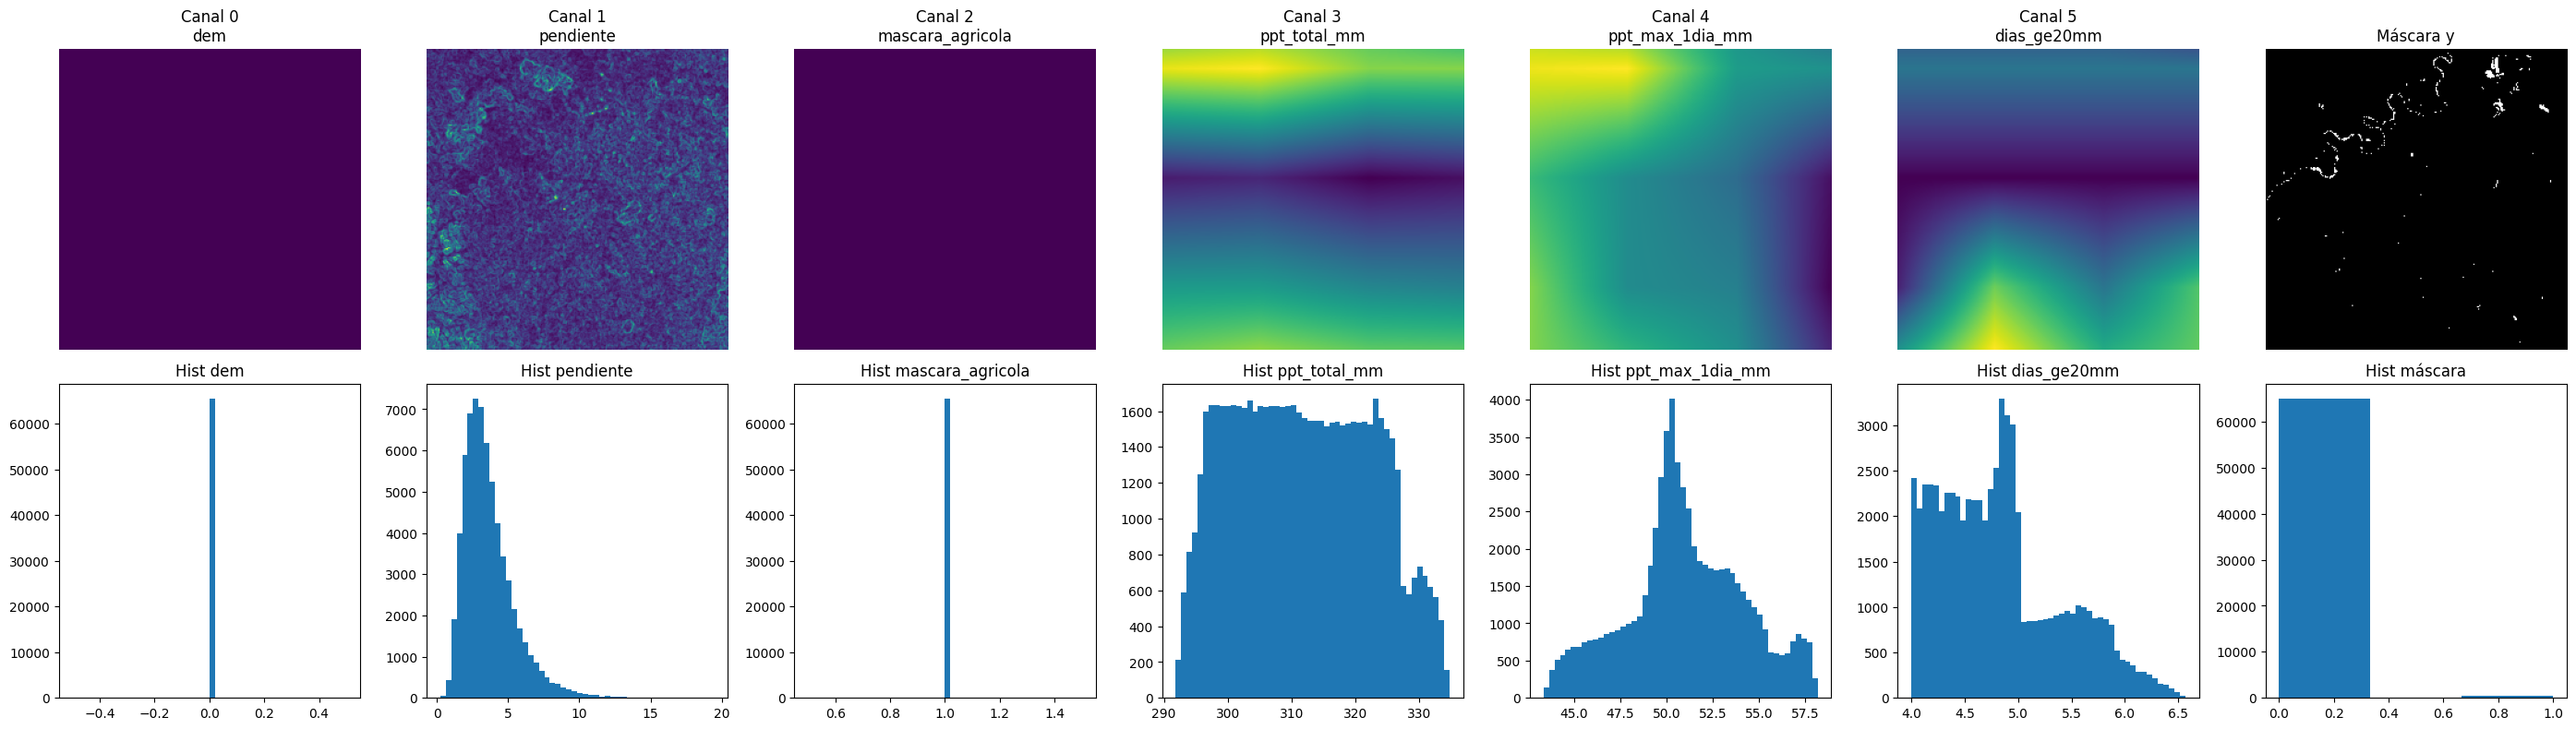

In [23]:
# Visualizacion
n_canales_mostrar = min(6, X.shape[0])

fig, axes = plt.subplots(2, n_canales_mostrar + 1, figsize=(4 * (n_canales_mostrar + 1), 8))

for i in range(n_canales_mostrar):
    axes[0, i].imshow(X[i], cmap="viridis")
    axes[0, i].set_title(f"Canal {i}\n{canales[i]}")
    axes[0, i].axis("off")

    # histograma del canal
    axes[1, i].hist(X[i].ravel(), bins=50)
    axes[1, i].set_title(f"Hist {canales[i]}")

# máscara
axes[0, -1].imshow(y, cmap="gray")
axes[0, -1].set_title("Máscara y")
axes[0, -1].axis("off")

axes[1, -1].hist(y.ravel(), bins=3)
axes[1, -1].set_title("Hist máscara")

plt.tight_layout()
plt.show()

Negativo

ARCHIVO: MEDIO_BAUDO_27430_2021_11_18_r384_c512_neg.npz
X.shape: (11, 256, 256)
y.shape: (256, 256)
dtype X: float32
dtype y: uint8
Número de canales: 11
Canales: ['dem', 'pendiente', 'mascara_agricola', 'ppt_total_mm', 'ppt_max_1dia_mm', 'dias_ge20mm', 'humedad_suelo_l1', 'runoff_superficial', 'temperatura_2m_c', 'ndvi', 'evi']
Pixeles positivos en y: 0
Proporción positiva: 0.0

META:
  archivo_label: MEDIO_BAUDO_27430_2021_11_18_mascara_inundacion_agricola.tif
  municipio: MEDIO_BAUDO
  codigo_municipio: 27430
  anio: 2021
  mes: 11
  dia: 18
  shape_x: [11, 885, 786]
  shape_y: [885, 786]
  canales: ['dem', 'pendiente', 'mascara_agricola', 'ppt_total_mm', 'ppt_max_1dia_mm', 'dias_ge20mm', 'humedad_suelo_l1', 'runoff_superficial', 'temperatura_2m_c', 'ndvi', 'evi']
  crs: EPSG:4326
  transform: [0.0005389891704717129, 0.0, -77.22043946431184, 0.0, -0.0005389891704717129, 5.385849285938591]
  factor_reduccion: 2
  split: train
  fila_inicio: 384
  col_inicio: 512
  pixeles_positivos: 

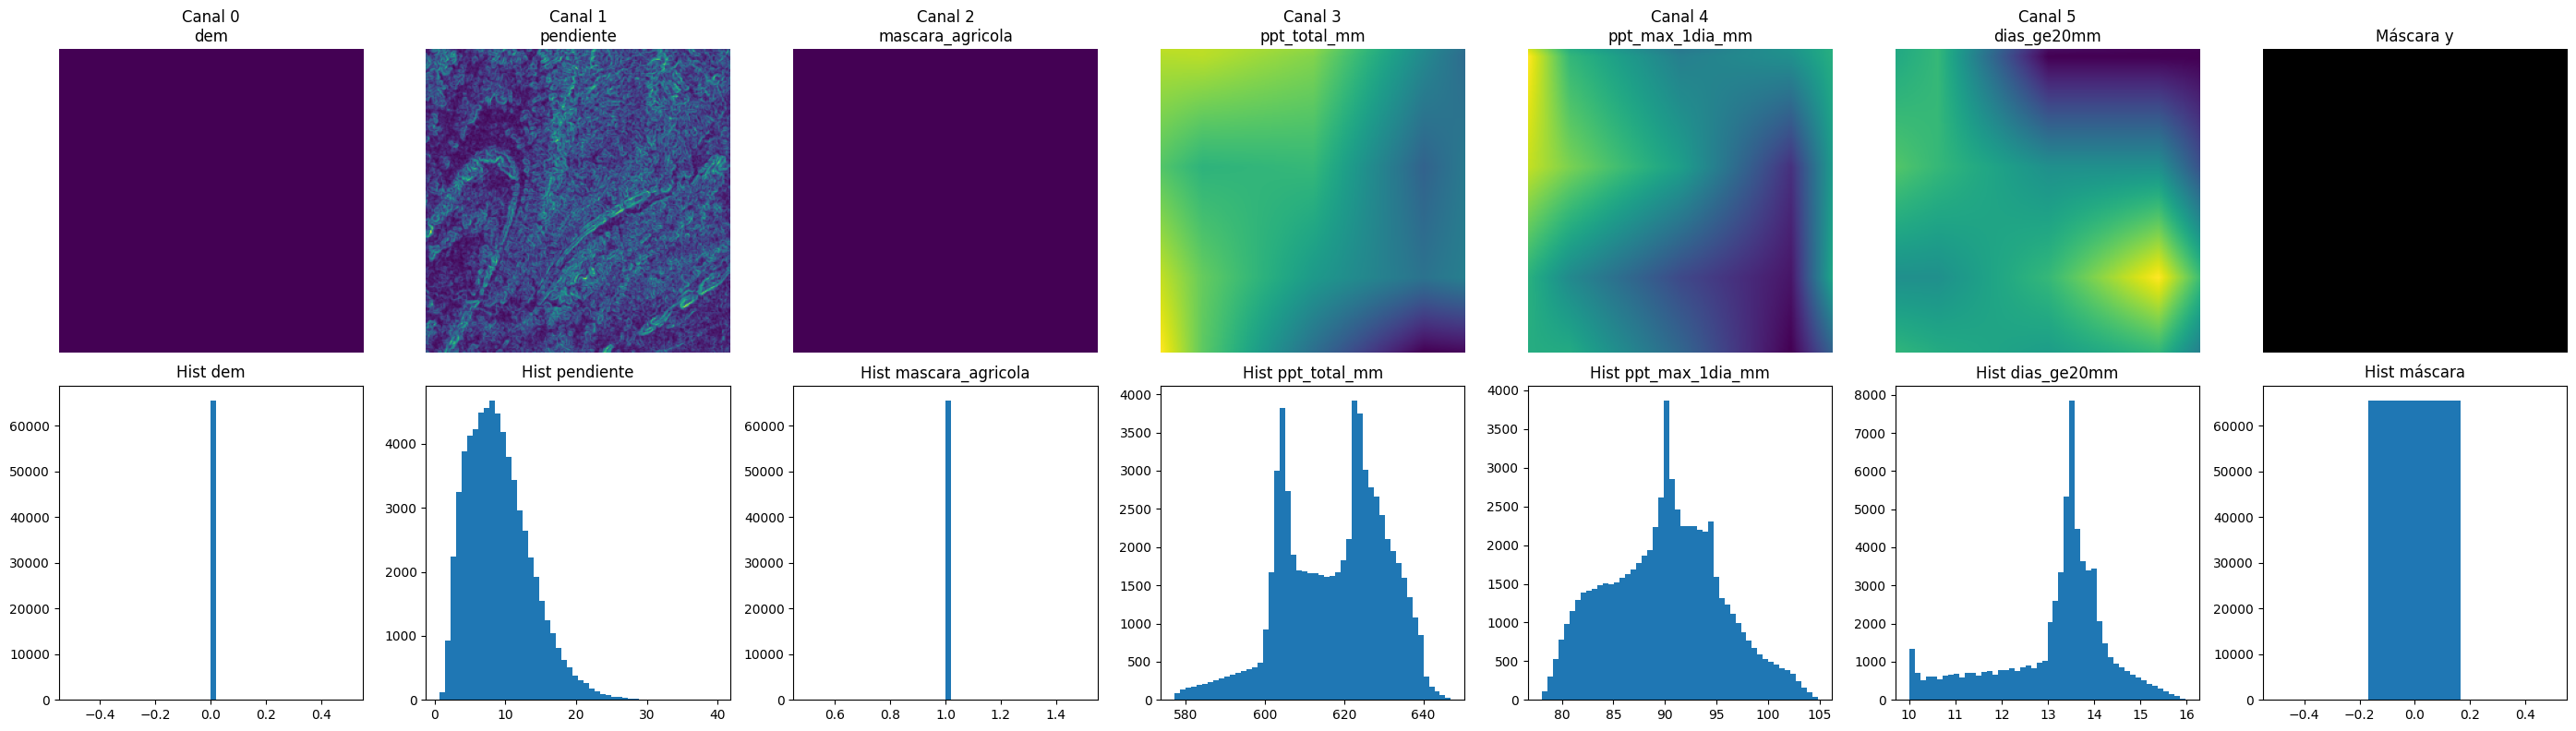

: 

In [ ]:
RUTA_PATCH = Path("../Data/Datos_U-Net/datos_procesados/parches_unet/train/MEDIO_BAUDO_27430_2021_11_18_r384_c512_neg.npz")

# =========================================================
# CARGA
# =========================================================
data = np.load(RUTA_PATCH, allow_pickle=True)

X = data["X"]          # [C, H, W]
y = data["y"]          # [H, W]
canales = data["canales"]

meta = None
if "meta_json" in data.files:
    meta = json.loads(str(data["meta_json"]))

print("=" * 70)
print("ARCHIVO:", RUTA_PATCH.name)
print("=" * 70)
print("X.shape:", X.shape)
print("y.shape:", y.shape)
print("dtype X:", X.dtype)
print("dtype y:", y.dtype)
print("Número de canales:", len(canales))
print("Canales:", list(canales))
print("Pixeles positivos en y:", int(y.sum()))
print("Proporción positiva:", float(y.mean()))

if meta is not None:
    print("\nMETA:")
    for k, v in meta.items():
        print(f"  {k}: {v}")

# =========================================================
# ESTADISTICAS POR CANAL
# =========================================================
print("\n" + "=" * 70)
print("ESTADISTICAS POR CANAL")
print("=" * 70)

for i, nombre in enumerate(canales):
    banda = X[i]
    print(
        f"{i:02d} | {nombre:30s} | "
        f"min={np.nanmin(banda):10.4f} | "
        f"max={np.nanmax(banda):10.4f} | "
        f"mean={np.nanmean(banda):10.4f} | "
        f"std={np.nanstd(banda):10.4f}"
    )

# =========================================================
# VISUALIZACION RAPIDA
# Muestra hasta 6 canales + mascara
# =========================================================
n_canales_mostrar = min(6, X.shape[0])

fig, axes = plt.subplots(2, n_canales_mostrar + 1, figsize=(4 * (n_canales_mostrar + 1), 8))

for i in range(n_canales_mostrar):
    axes[0, i].imshow(X[i], cmap="viridis")
    axes[0, i].set_title(f"Canal {i}\n{canales[i]}")
    axes[0, i].axis("off")

    # histograma del canal
    axes[1, i].hist(X[i].ravel(), bins=50)
    axes[1, i].set_title(f"Hist {canales[i]}")

# máscara
axes[0, -1].imshow(y, cmap="gray")
axes[0, -1].set_title("Máscara y")
axes[0, -1].axis("off")

axes[1, -1].hist(y.ravel(), bins=3)
axes[1, -1].set_title("Hist máscara")

plt.tight_layout()
plt.show()

## Descargar el dataset

In [ ]:
asdas #Llave de control
guadar_preparados(data_complete, esta)

NameError: name 'asdas' is not defined